In [ ]:
import polars as pl
import numpy as np
from glum import GeneralizedLinearRegressor
from glum import TweedieDistribution
import scipy.optimize as optimize
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sklearn

In [35]:
sklearn.set_config(transform_output="polars")

In [6]:
claim_freq = pl.read_csv('freMTPL2freq.csv', schema_overrides={
    'IDpol': pl.Float64})
claim_freq = claim_freq.with_columns(pl.col('IDpol').cast(pl.Int64))

In [7]:
total_exposure = claim_freq['Exposure'].sum()

df_plot = (
    claim_freq.select(['ClaimNb', 'Exposure'])
    .group_by('ClaimNb')
    .agg(pl.col('Exposure').sum())
    .with_columns(
        (pl.col('Exposure') / total_exposure).alias('Frequency_Observed')
    )
)

In [8]:
df_plot = df_plot.sort('ClaimNb')

In [9]:
mean = claim_freq["ClaimNb"].sum() / claim_freq["Exposure"].sum()
mean

0.10070308464041308

In [10]:
x = range(5)


In [11]:
df_plot.head()

ClaimNb,Exposure,Frequency_Observed
i64,f64,f64
0,336616.05977,0.938958
1,20670.757404,0.057659
2,1153.418289,0.003217
3,52.76,0.000147
4,3.07,0.000009


<Axes: ylabel='Frequency_Observed'>

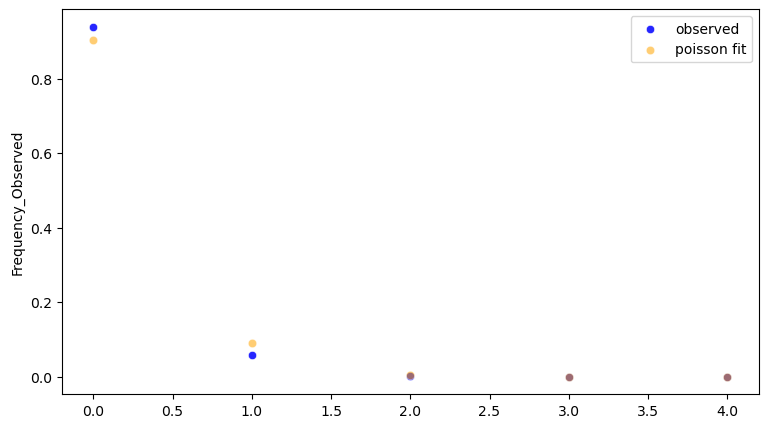

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(x=x, y=df_plot["Frequency_Observed"].head(5), alpha=0.85, color="blue", ax=ax, label="observed")
sns.scatterplot(x=x, y=stats.poisson.pmf(x, mean), alpha=0.55, color="orange", ax=ax, label="poisson fit")

In [13]:
labels = (claim_freq["ClaimNb"] / claim_freq["Exposure"]).alias("Frequency")
labels.head()

Frequency
f64
10.0
1.298701
1.333333
11.111111
1.190476
1.923077
2.222222
3.703704
1.408451


In [14]:
claim_freq.head()

IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
i64,i64,f64,str,i64,i64,i64,i64,str,str,i64,str
1,1,0.1,"""'D'""",5,0,55,50,"""'B12'""","""'Regular'""",1217,"""'R82'"""
3,1,0.77,"""'D'""",5,0,55,50,"""'B12'""","""'Regular'""",1217,"""'R82'"""
5,1,0.75,"""'B'""",6,2,52,50,"""'B12'""","""'Diesel'""",54,"""'R22'"""
10,1,0.09,"""'B'""",7,0,46,50,"""'B12'""","""'Diesel'""",76,"""'R72'"""
11,1,0.84,"""'B'""",7,0,46,50,"""'B12'""","""'Diesel'""",76,"""'R72'"""


In [42]:
categoricals = ["VehBrand", "VehGas", "Region", "Area"]
predictors = categoricals + ["BonusMalus", "Density", "DrivAge", "VehAge", "VehPower"]
features = claim_freq.with_columns([pl.col(x).str.replace_all("'","").cast(pl.Categorical) for x in categoricals])

In [43]:
features.head()

IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
i64,i64,f64,cat,i64,i64,i64,i64,cat,cat,i64,cat
1,1,0.1,"""D""",5,0,55,50,"""B12""","""Regular""",1217,"""R82"""
3,1,0.77,"""D""",5,0,55,50,"""B12""","""Regular""",1217,"""R82"""
5,1,0.75,"""B""",6,2,52,50,"""B12""","""Diesel""",54,"""R22"""
10,1,0.09,"""B""",7,0,46,50,"""B12""","""Diesel""",76,"""R72"""
11,1,0.84,"""B""",7,0,46,50,"""B12""","""Diesel""",76,"""R72"""


In [44]:
labels = (claim_freq["ClaimNb"] / claim_freq["Exposure"]).alias("Frequency")
weight = claim_freq["Exposure"].alias("Weight")
num_claims = claim_freq["ClaimNb"].alias("NumClaims")
features = features.drop("IDpol", "ClaimNb", "Exposure")

In [45]:
features_dummied = features.to_dummies(columns=categoricals, drop_first=True)
features_dummied.head()

Area_A,Area_B,Area_C,Area_E,Area_F,VehPower,VehAge,DrivAge,BonusMalus,VehBrand_B1,VehBrand_B10,VehBrand_B11,VehBrand_B13,VehBrand_B14,VehBrand_B2,VehBrand_B3,VehBrand_B4,VehBrand_B5,VehBrand_B6,VehGas_Diesel,Density,Region_R11,Region_R21,Region_R22,Region_R23,Region_R24,Region_R25,Region_R26,Region_R31,Region_R41,Region_R42,Region_R43,Region_R52,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R83,Region_R91,Region_R93,Region_R94
u8,u8,u8,u8,u8,i64,i64,i64,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
0,0,0,0,0,5,0,55,50,0,0,0,0,0,0,0,0,0,0,0,1217,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,5,0,55,50,0,0,0,0,0,0,0,0,0,0,0,1217,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,1,0,0,0,6,2,52,50,0,0,0,0,0,0,0,0,0,0,1,54,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,1,0,0,0,7,0,46,50,0,0,0,0,0,0,0,0,0,0,1,76,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
0,1,0,0,0,7,0,46,50,0,0,0,0,0,0,0,0,0,0,1,76,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [46]:
X_train, X_test, y_train, y_test, weight_train, weight_test, num_claims_train, num_claims_test = \
    train_test_split(features_dummied, labels, weight, num_claims, test_size=0.1, random_state=42)

In [47]:
f_glm1 = GeneralizedLinearRegressor(family='poisson', alpha_search=True, l1_ratio=1, fit_intercept=True)

In [48]:
f_glm1.fit(X_train, y_train, sample_weight=weight_train)

GeneralizedLinearRegressor(alpha_search=True, family='poisson', l1_ratio=1)

In [50]:
pl.DataFrame(
    {'coefficient': [f_glm1.intercept_] + f_glm1.coef_.tolist()},
    schema={'coefficient': pl.Float64}
).with_columns(
    pl.Series(['intercept'] + f_glm1.feature_names_).alias('feature')
).select(['feature', 'coefficient'])

feature,coefficient
str,f64
"""intercept""",-3.552383
"""Area_A""",-0.175783
"""Area_B""",-0.134359
"""Area_C""",-0.097086
"""Area_E""",0.028703
…,…
"""Region_R74""",0.058906
"""Region_R83""",-0.275204
"""Region_R91""",-0.047836


In [53]:
PoissonDist = TweedieDistribution(1)
print('training loss f_glm1: {}'.format(
    PoissonDist.deviance(y_train, f_glm1.predict(X_train), sample_weight=weight_train)/weight_train.sum()
))

print('test loss f_glm1: {}'.format(
      PoissonDist.deviance(y_test, f_glm1.predict(X_test), sample_weight=weight_test)/weight_test.sum()))

training loss f_glm1: 0.6074042770555854
test loss f_glm1: 0.5950564354285557
